## Imports

In [1]:
from pathlib import Path
import zipfile
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx
import random
from shapely.geometry import LineString, Polygon, Point, MultiPolygon
import numpy as np
import networkx as nx
from itertools import combinations
import osmnx as ox
import tobler
from collections import defaultdict
import pickle
import sys
import math 
import os

sys.path.append(str(Path.cwd().parent))

from src import preprocessing
from src import algorithms
from src import visualizations


### Output folder setup

This cell defines the current experiment cycle and creates the results folder for that run.

- `version = "01"` sets the current cycle
- `path = f"../Results/Synthetic/Cycle_{version}"` creates `Results/Synthetic/Cycle_01`
- if you want to run cycle 02, change `version = "01"` to `version = "02"` and rerun the notebook

Later in the notebook, the pickle/plot save lines are currently commented out. Once you want to store results for this cycle, uncomment those lines.

To run 10 cycles, either:
- change `version` manually for each cycle and run the notebook 10 times, or
- refactor the notebook to loop over `version` values automatically

In [2]:
version = "rerun"

path = f"../Results/Synthetic/Cycle_{version}"
os.makedirs(path, exist_ok=True)

## Parameters for creating the map of copenhagen

In [3]:
# parameters of the grid
resolution = 8

prompt = "Copenhagen Municipality, Denmark" 

prompt_2 = "Frederiksberg Municipality, Denmark" 

prompt_3 = "Tårnby Municipality, Denmark"

proj_crs = "EPSG:2062"

## Grid creation with function from src/preprocessing.py

In [4]:
grid, points, my_polygon = preprocessing.Create_grid_1(resolution, prompt, proj_crs, prompt_2, prompt_3, return_points=True)

/home/jspe/venvs/Bachelor_project/lib/python3.11/site-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)


### Evaluate the grid to see if it looks as expected.

Text(0.5, 1.0, 'Grid over Copenhagne DK.')

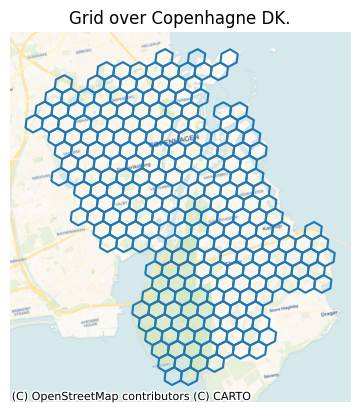

In [5]:
fig, ax = plt.subplots(1,1)
grid.boundary.plot(ax=ax)
cx.add_basemap(ax=ax, source=cx.providers.CartoDB.Voyager, crs = grid.crs)
ax.set_axis_off()
ax.set_title("Grid over Copenhagne DK.")

### Additional visualisation of grid with study area boundaries

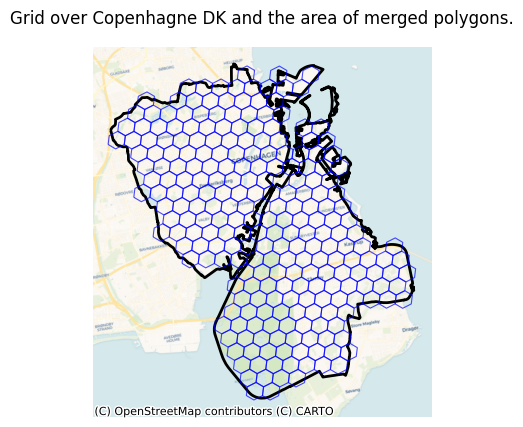

In [6]:
fig, ax = plt.subplots(1,1)
## Plot polygon boundary
my_polygon.boundary.plot(ax=ax, linewidth=2, color="black") # merged boundaries

## Plot grid on top
grid.boundary.plot(ax=ax, linewidth=0.8, color="blue", alpha=0.7)

cx.add_basemap(ax=ax, source=cx.providers.CartoDB.Voyager, crs = grid.crs)
ax.set_axis_off()
ax.set_title("Grid over Copenhagne DK and the area of merged polygons.")

plt.show()

## Create the OD matrix - creating the pair list and random weight assigned to this pair
#### If data isnt created or new travel data needs to be generated, use the following line to create the OD matrix and save it as a CSV. 


In [7]:
# od_df_tocsv = preprocessing.generate_trip_weight(points, 10, 380)
# od_df_tocsv.to_csv("../data/synthetic_od_data_matrix.csv", index=False)

#### If you already have the CSV, you can skip this step and directly load it with pd.read_csv() as shown in the next cell.

In [8]:
od_df = pd.read_csv("../data/synthetic_od_data_matrix.csv")

## Calculate weight for each hexagon based on previuoslyu created OD matrix and extract total demand

In [9]:
## Calculating the weights for each point based on the OD matrix
pointes_weighted = preprocessing.create_weights(points, od_df)

## Finding total system demand
total_demand = od_df["weight"].sum()

#### Precompute symmetric OD pair weights for faster scoring. This aggregates od_df demand into a dictionary keyed by unordered origin-destination pairs

In [10]:
## Optimized version of calc_score, so time is decreased
pair_weights = defaultdict(float)
for row in od_df.itertuples():
    o, d, w = row.o, row.d, row.weight
    key = (min(o, d), max(o, d))
    pair_weights[key] += w

## Find the valid neighbor moves for the GA route-building logic

In [11]:
## Finding the surrounding/connecting hexagons to each hexagon
valid_connections = preprocessing.finding_neighbors(pointes_weighted, grid)


## attach the neighbor list (`vicinity`) to the base grid so each hexagon has valid next moves
possible_neighbors = grid.merge(
    valid_connections[["cell_id", "vicinity"]],
    on="cell_id",
    how="left"
)

### Visulise the demand, so it is assigned weight to hexagons based on origin destination created matrix

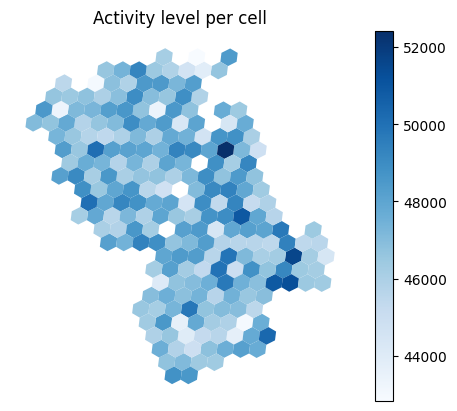

In [12]:
grid_heatmap = grid.merge(
    pointes_weighted[["cell_id", "weight"]],
    on="cell_id",
    how="left"
)

grid_heatmap["weight_int"] = grid_heatmap["weight"].astype(int)

fig, ax = plt.subplots(1,1)
grid_heatmap.plot(
    ax=ax,
    column="weight_int",
    cmap = "Blues",
    legend=True
)
ax.set_axis_off()
ax.set_title("Activity level per cell");

## The Genetic algorithm section

### Set the parameters

In [13]:
# parameters of metro lines
max_routes = 4
max_stops = 17
min_stops = 6 # Becuase existing network have a line of 6 unique stations, M1 part

# parameters of GA algorithms
total_kids = 40
num_of_generations = 20

# parameters for selecting parents later
top_performers = 3
random_performers = 3
sample_size = 3
number_of_parents = 10

### Creation of initial population, defined as list of accepted_kids

In [14]:
# Creating initial population of kids
accepted_kids = []

while len(accepted_kids) < total_kids:
    all_routes = {}
    potential_start = pointes_weighted["cell_id"].tolist()

    routes = 0

    while routes < max_routes:
        if not potential_start:
            break

        route_current = []
        start_node = random.choice(potential_start)
        route_current.append(start_node)
        has_reversed = False

        while len(route_current) < max_stops:

            if random.random() < 0.05 and len(route_current) >= min_stops:  # 5% chance to break
                break

            curr_node = route_current[-1]

            if curr_node in potential_start:
                potential_start.remove(curr_node)

            # filter out nodes already in this route
            vicinity_current = valid_connections.loc[valid_connections.cell_id==curr_node, "vicinity"].values[0]
            poss_neighbors = [n for n in vicinity_current if n not in route_current]

            # find the possible neighbors and their weights
            neighbor_nodes, neighbor_weights = algorithms.TriangleCheck(poss_neighbors, valid_connections, route_current)

            # dead-end handling
            route_current, restart, has_reversed = algorithms.deadend_handeling(neighbor_nodes, route_current, min_stops, has_reversed)

            if restart:
                continue

            if not neighbor_nodes:
                break

            next_node = random.choices(neighbor_nodes, weights=neighbor_weights, k=1)[0]

            route_current.append(next_node)        

        if len(route_current) >= min_stops:
            all_routes[routes] = route_current
            routes += 1
        else:
            continue
                
    G = nx.Graph()
    
    for route_id, route in all_routes.items():
        if not isinstance(route_id, int):
            continue

        for u, v in zip(route[:-1], route[1:]):
            G.add_edge(u, v, route=route_id)
            
    if G.number_of_nodes() == 0:
        continue
            
    is_one_component = nx.is_connected(G)

    ## If it is one componnet, then calculate the demand score and add it to the accepted kids
    if is_one_component: 
        (all_routes["Score as %"], all_routes["AVG_Shortest Path"], all_routes["Average transfers"]) = \
            algorithms.cal_scoreV2(G, od_df, valid_connections, pair_weights)
        all_routes["Number of edges"] = G.number_of_edges()
        all_routes["Number of nodes"] = G.number_of_nodes()
        accepted_kids.append(all_routes)
    else:
        continue

### Return any kid from the initial popualtion by defining its identifier in a square brackets.

In [15]:
# accepted_kids[6]

### Visualise the kids, the ids can be specified 

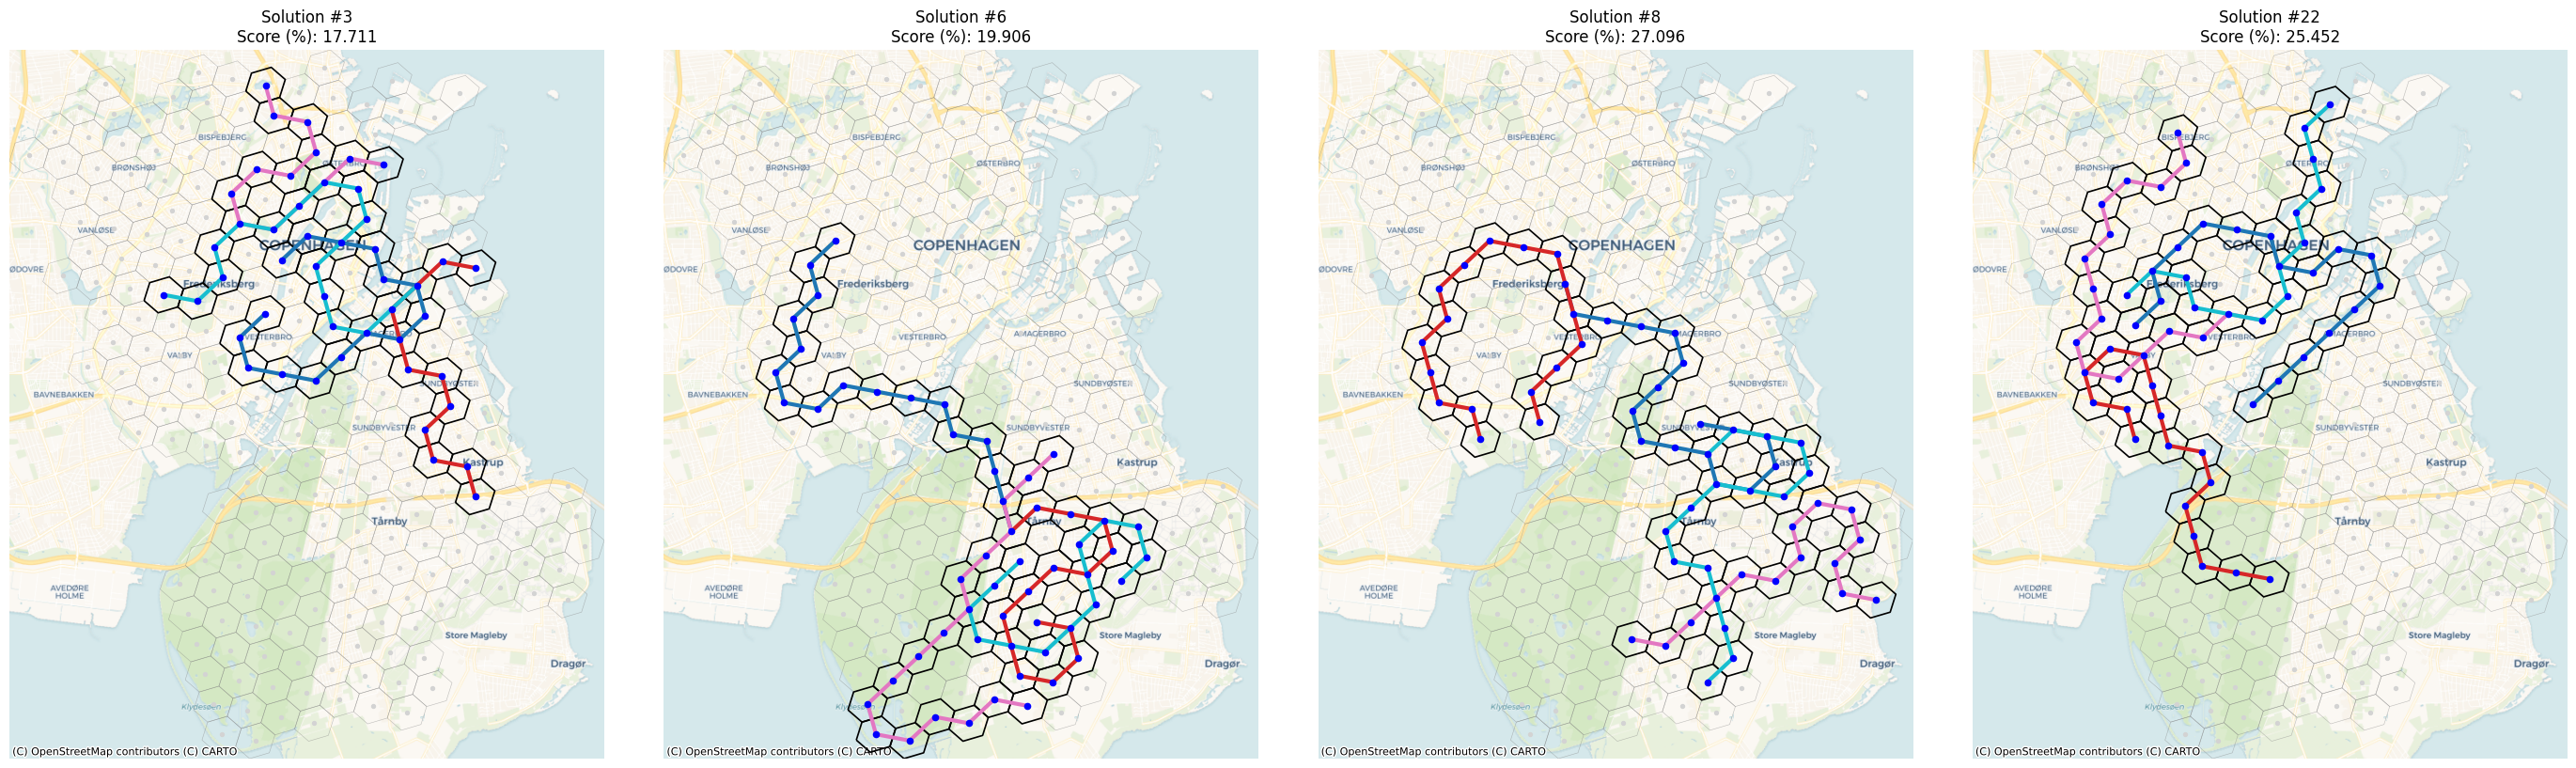

In [16]:
# -------- REPROJECT FOR PLOTTING --------
grid_plot = grid.to_crs(epsg=3857)
points_plot = pointes_weighted.to_crs(epsg=3857)

# -------- SELECT SUBSET --------
selected_indices = [3, 6, 8, 22]   # choose accepted_kids indices here
max_cols = 4

selected_solutions = [
    (i, accepted_kids[i])
    for i in selected_indices
    if 0 <= i < len(accepted_kids)
]

n = len(selected_solutions)

if n == 0:
    print("No valid accepted_kids indices selected.")

else:
    ncols = min(max_cols, n)
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(7 * ncols, 8 * nrows),
        sharex=True,
        sharey=True
    )

    axes = np.atleast_1d(axes).ravel()

    for plot_idx, (solution_idx, solution_dict) in enumerate(selected_solutions):
        ax = axes[plot_idx]

        score = solution_dict.get("Score as %", None)
        edges_gdf = visualizations.build_edges_gdf(solution_dict, points_plot)

        used_nodes = []
        for k, v in solution_dict.items():
            if isinstance(v, (list, tuple)):
                used_nodes.extend(v)

        used_nodes = list(set(used_nodes))

        used_points = points_plot[
            points_plot["cell_id"].isin(used_nodes)
        ]

        used_hex = grid_plot[
            grid_plot["cell_id"].isin(used_nodes)
        ] if "cell_id" in grid_plot.columns else None

        ax.set_xlim(grid_plot.total_bounds[0], grid_plot.total_bounds[2])
        ax.set_ylim(grid_plot.total_bounds[1], grid_plot.total_bounds[3])

        cx.add_basemap(
            ax=ax,
            source=cx.providers.CartoDB.Voyager,
            crs=grid_plot.crs
        )

        grid_plot.boundary.plot(
            ax=ax,
            color="gray",
            linewidth=0.4,
            alpha=0.5,
            zorder=2
        )

        if used_hex is not None and not used_hex.empty:
            used_hex.boundary.plot(
                ax=ax,
                color="black",
                linewidth=1.2,
                zorder=3
            )

        if not edges_gdf.empty:
            edges_gdf.plot(
                ax=ax,
                column="route_id",
                categorical=True,
                legend=False,
                linewidth=3,
                zorder=4
            )

        points_plot.plot(
            ax=ax,
            color="lightgray",
            markersize=8,
            zorder=5
        )

        if not used_points.empty:
            used_points.plot(
                ax=ax,
                color="blue",
                markersize=20,
                zorder=6
            )

        if isinstance(score, (int, float)):
            ax.set_title(f"Solution #{solution_idx}\nScore (%): {score:.3f}")
        elif score is not None:
            ax.set_title(f"Solution #{solution_idx}\nScore (%): {score}")
        else:
            ax.set_title(f"Solution #{solution_idx}")

        ax.set_axis_off()
        ax.set_aspect("equal")

    for j in range(n, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

### Visualise correlation between demand score and amount of edges

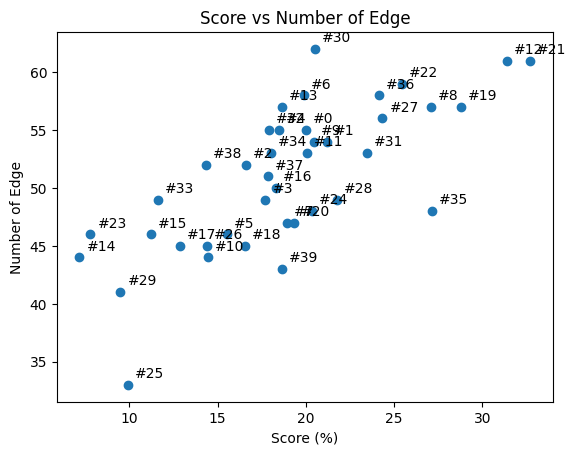

In [17]:
x = [d["Score as %"] for d in accepted_kids]
y = [d["Number of edges"] for d in accepted_kids]

for i in range(len(x)):
    plt.annotate(f"#{i}",
                 (x[i], y[i]),
                 textcoords="offset points",
                 xytext=(5,5),
                 ha='left')

plt.scatter(x, y)
plt.xlabel("Score (%)")
plt.ylabel("Number of Edge")
plt.title("Score vs Number of Edge")
plt.show()

## Running GA

### Launching the parent selection function to pre-identify 10 kids out of 40 as parents

In [18]:
parents_of_new_gen = algorithms.select_parents(accepted_kids, top_performers, random_performers, sample_size, number_of_parents)

### This section creates multiple generations of transport networks using crossover operations 

For each generated network:
- Routes are converted into a graph structure
- Connectivity is validated using NetworkX
- evaluation metrics are calculated
- Graph statistics (edges/nodes) are stored

The final generations can be exported as a  `.pkl` dataset for later analysis

In [19]:
generations = {}
gen_id = 1

OG_pop = {index: value for index, value in enumerate(accepted_kids)}
OG_pop = algorithms.normalize_generation(OG_pop)
generations[0] = OG_pop

while len(generations) < num_of_generations:
    kids = {}
    kid_id = 0
    while len(kids) < total_kids:
        new_kid = algorithms.crossover(parents_of_new_gen, possible_neighbors, 0.1, valid_connections)
               
        G = nx.Graph() 
        for route_id, route in new_kid.items():
            if not isinstance(route_id, int):
                continue

            for u, v in zip(route[:-1], route[1:]):
                G.add_edge(u, v, route=route_id)

        is_one_component = nx.is_connected(G)
        
        if is_one_component: # false then skip
            kids[kid_id] = new_kid
            (kids[kid_id]["Score as %"], kids[kid_id]["AVG_Shortest Path"], kids[kid_id]["Average transfers"]) \
            = algorithms.cal_scoreV2(G, od_df, valid_connections, pair_weights)
            kids[kid_id]["Number of edges"] = G.number_of_edges()
            kids[kid_id]["Number of nodes"] = G.number_of_nodes()
            kid_id += 1

    kids = algorithms.normalize_generation(kids)
    generations[gen_id] = kids
    gen_id += 1

# UNCOMMENT THIS PART TO SAVE THE GENERATIONS DATA AS PICKLE FILE

# with open(f"../Results/Synthetic/Cycle_{version}/{version}_gen_data.pkl", "wb") as f:
    # pickle.dump(generations, f)

#### Generation Validation

In [20]:
print(len(generations)) # 20 generations
print(len(generations[0])) # 40 kids
print(len(generations[19][2])) # 14 values - 4 lines and 10 metadata values

20
40
14


## Performance visualisation with Demand coverage % vs Edge amount

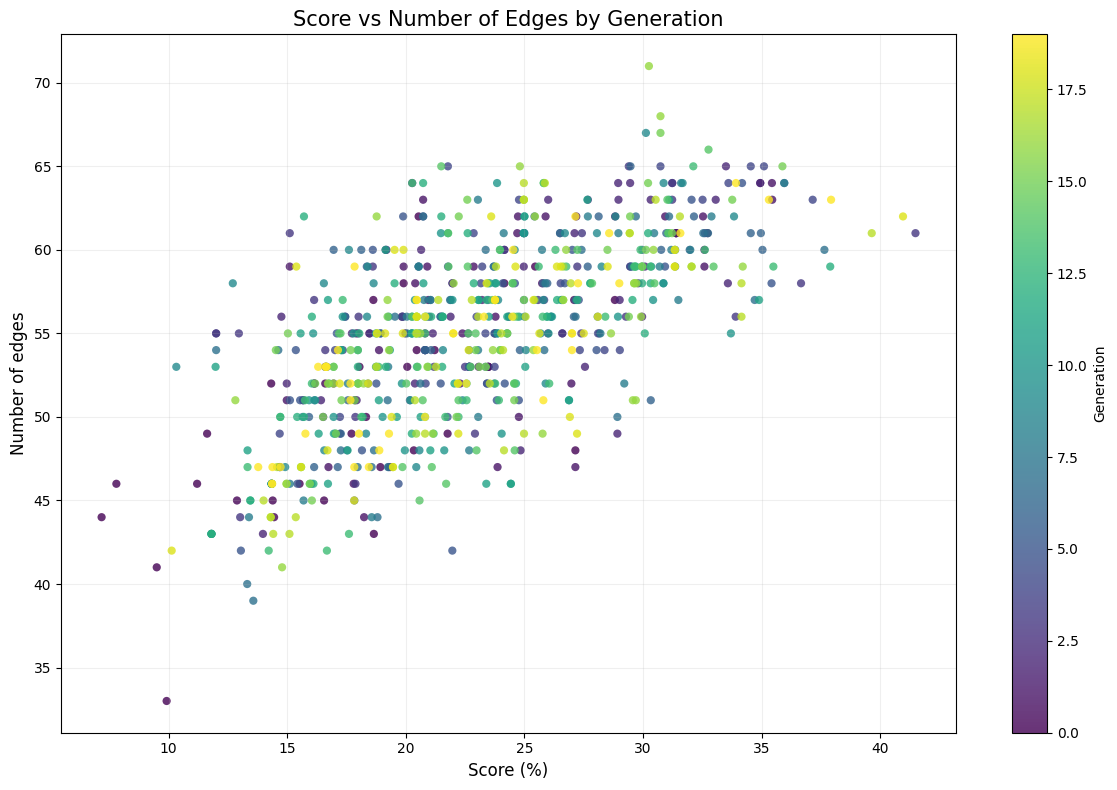

In [21]:
# Collect all data first
x = []
y = []
gen_vals = []

for gen_name, kids_dict in generations.items():
    for kid_info in kids_dict.values():
        x.append(kid_info["Score as %"])
        y.append(kid_info["Number of edges"])
        gen_vals.append(int(gen_name))   # assumes generation names are numeric strings

# Create larger figure
plt.figure(figsize=(12, 8))

# Scatter plot with continuous colormap
scatter = plt.scatter(
    x,
    y,
    c=gen_vals,          # color by generation
    cmap="viridis",      # continuous colormap
    s=35,                # smaller points
    alpha=0.8,
    edgecolors="none"
)

# Labels and title
plt.xlabel("Score (%)", fontsize=12)
plt.ylabel("Number of edges", fontsize=12)
plt.title("Score vs Number of Edges by Generation", fontsize=15)

# Add colorbar instead of legend
cbar = plt.colorbar(scatter)
cbar.set_label("Generation")

# Optional styling
plt.grid(True, alpha=0.2)
plt.tight_layout()

# UNCOMMENT THIS PART TO SAVE THIS PLOT

# plt.savefig(f"../Results/Synthetic/Cycle_{version}/{version}_generation_plot_1.png", dpi=300, bbox_inches="tight")

plt.show()

## Performance visualisation with Demand coverage % acroos generations 

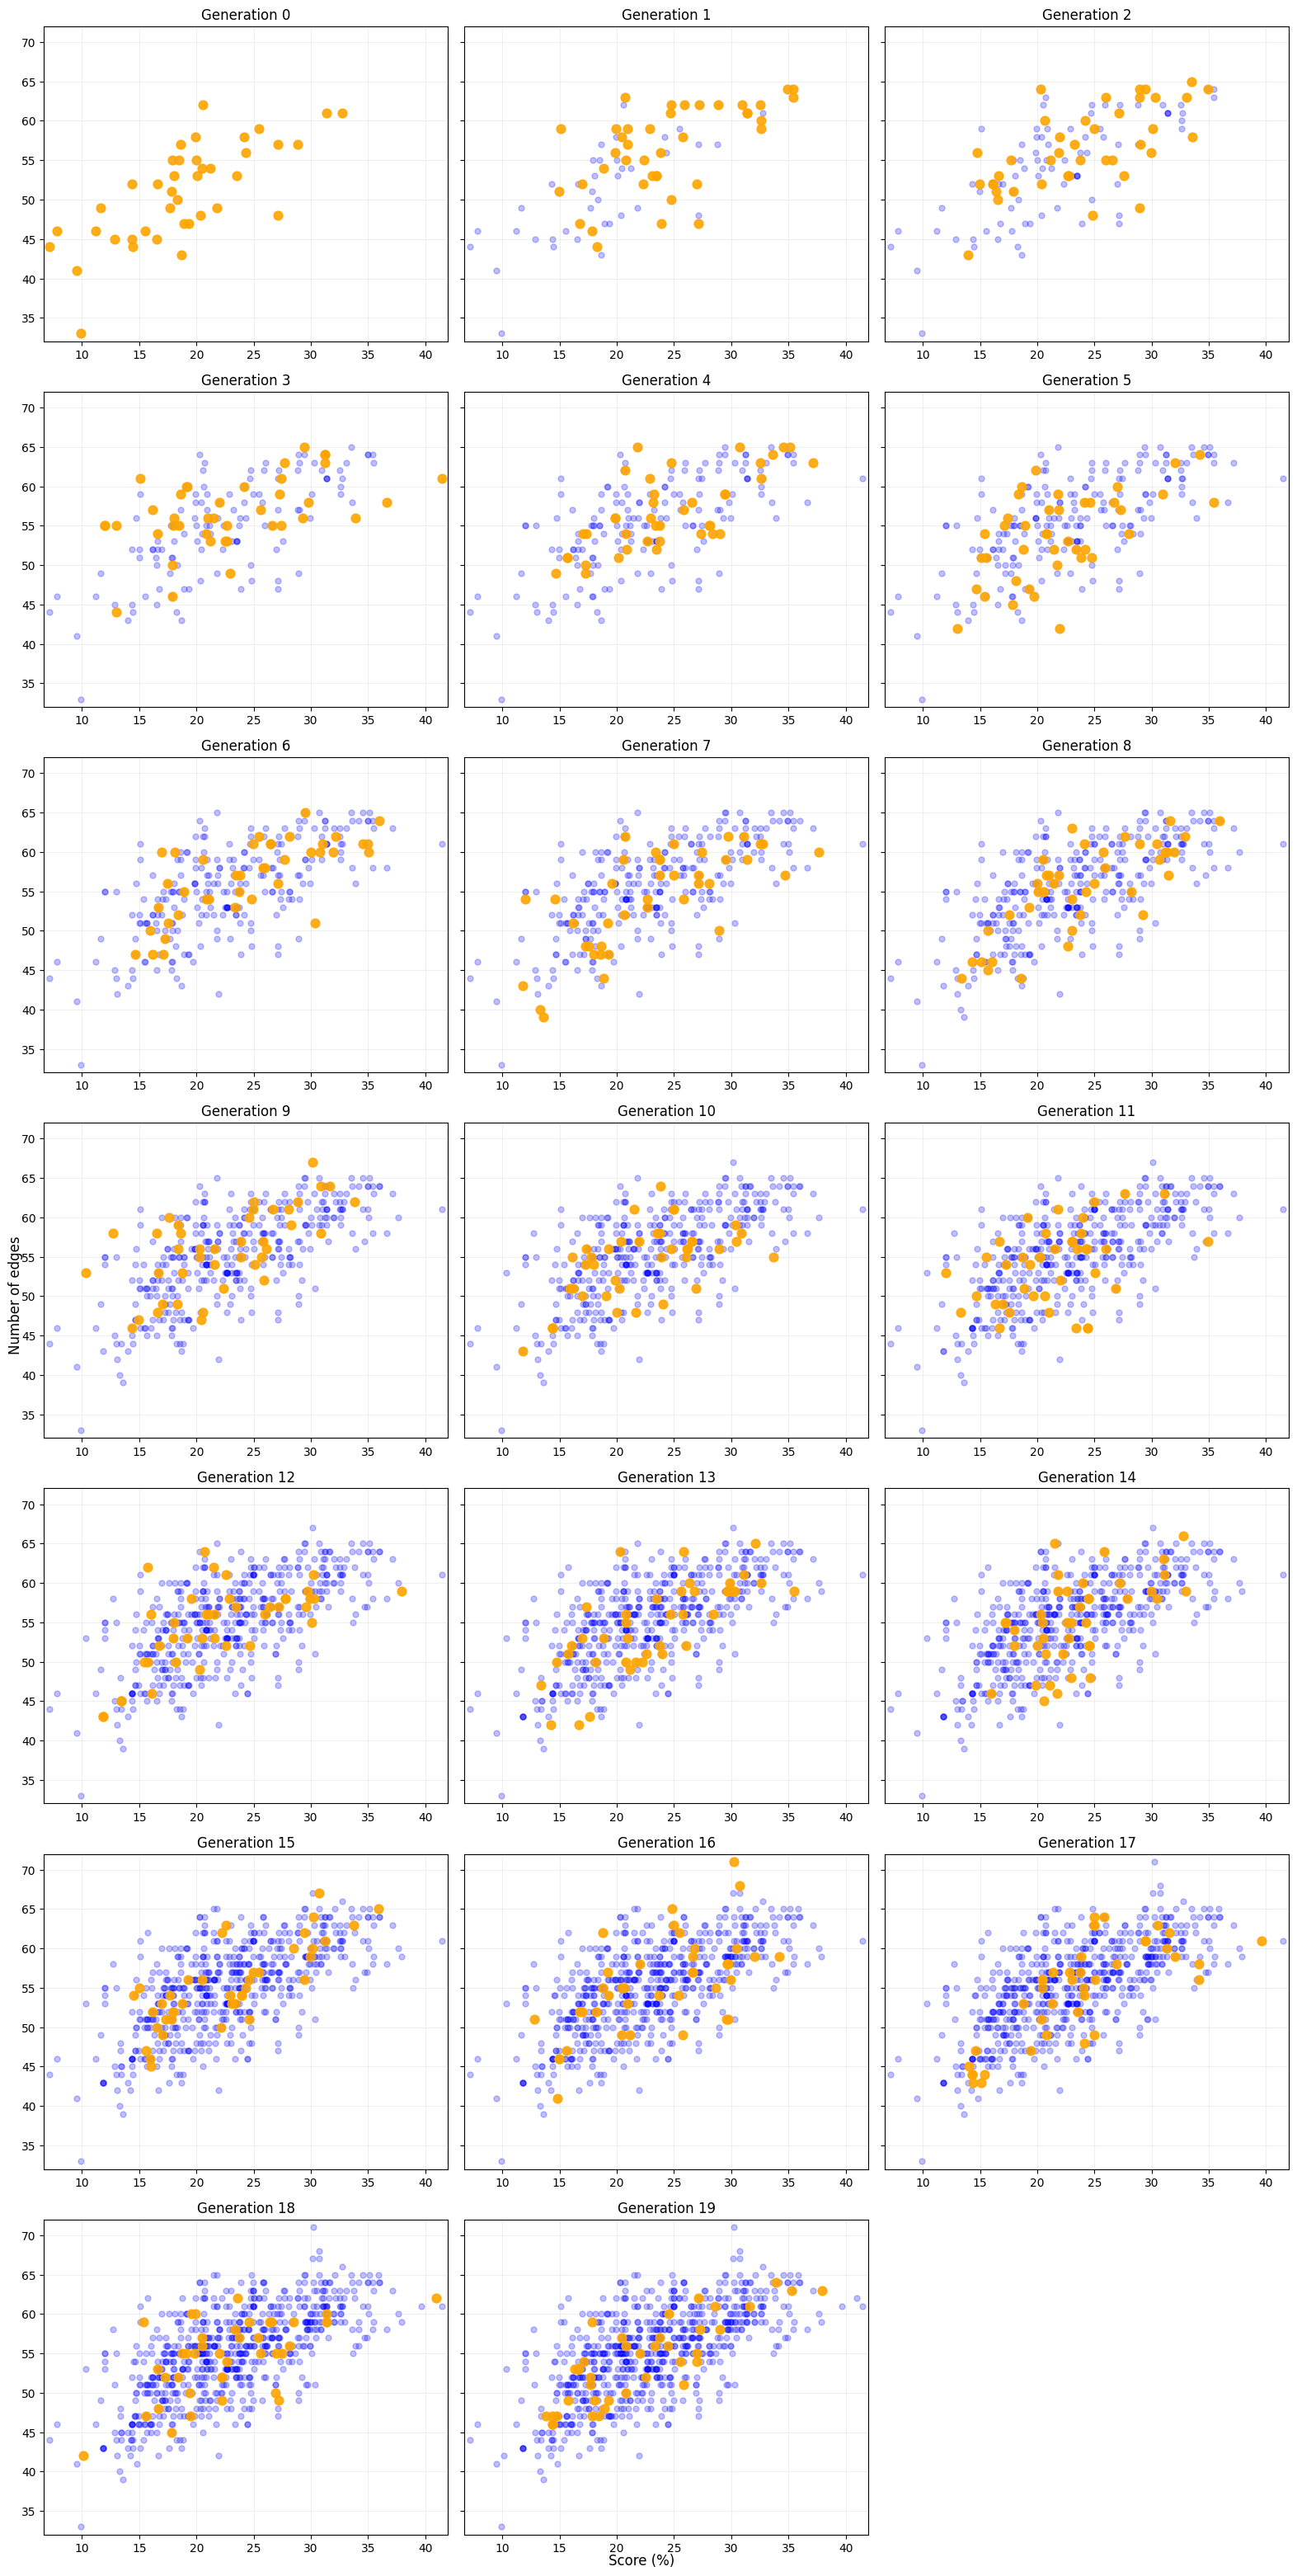

In [22]:
# Flatten data by generation
gen_data = {}

for gen_name, kids_dict in generations.items():
    gen = int(gen_name)
    gen_data[gen] = {
        "x": [kid_info["Score as %"] for kid_info in kids_dict.values()],
        "y": [kid_info["Number of edges"] for kid_info in kids_dict.values()],
    }

gens = sorted(gen_data.keys())

# Shared axis limits for easier comparison
all_x = [v for gen in gens for v in gen_data[gen]["x"]]
all_y = [v for gen in gens for v in gen_data[gen]["y"]]

x_pad = 0.5
y_pad = 1

ncols = 3
nrows = math.ceil(len(gens) / ncols)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(16, 4.5 * nrows),
    sharex=False,
    sharey=True
)

axes = axes.flatten()

for ax, gen in zip(axes, gens):
    # Previous generations
    prev_x = [v for g in gens if g < gen for v in gen_data[g]["x"]]
    prev_y = [v for g in gens if g < gen for v in gen_data[g]["y"]]

    if prev_x:
        ax.scatter(
            prev_x,
            prev_y,
            s=25,
            alpha=0.25,
            label="Previous generations",
            color="blue"
        )

    # Current generation highlighted
    ax.scatter(
        gen_data[gen]["x"],
        gen_data[gen]["y"],
        s=60,
        alpha=0.9,
        label=f"Generation {gen}",
        color="orange"
    )

    ax.set_title(f"Generation {gen}")
    ax.grid(True, alpha=0.2)
    ax.set_xlim(min(all_x) - x_pad, max(all_x) + x_pad)
    ax.set_ylim(min(all_y) - y_pad, max(all_y) + y_pad)

# Remove empty subplot slots
for ax in axes[len(gens):]:
    ax.remove()

fig.supxlabel("Score (%)")
fig.supylabel("Number of edges")


plt.tight_layout()

# UNCOMMENT THIS PART TO SAVE THIS PLOT

# plt.savefig(f"../Results/Synthetic/Cycle_{version}/{version}_generation_plot_2.png", dpi=300, bbox_inches="tight")

plt.show()

## Extract average demand score (%) per generation

In [23]:
# Calcuulate the average score for each genration
for i in range(len(generations)):
    generation_total = 0
    for j in range(len(generations[i])):
        generation_total += generations[i][j]["Score as %"].sum()
    # print(f"Generation {i}: {generation_total}")
    print(f"Generation {i} average: {generation_total / len(generations[i])}")
   

Generation 0 average: 18.86612503647561
Generation 1 average: 24.515341319535377
Generation 2 average: 23.944922351731652
Generation 3 average: 23.05914239625711
Generation 4 average: 24.532790051088462
Generation 5 average: 21.847044858304216
Generation 6 average: 24.523816790362027
Generation 7 average: 23.0968048757499
Generation 8 average: 23.85367898472772
Generation 9 average: 22.405262973926423
Generation 10 average: 22.011238574308866
Generation 11 average: 21.39771100118287
Generation 12 average: 21.899664511345087
Generation 13 average: 23.303207697249142
Generation 14 average: 23.411426351962586
Generation 15 average: 22.7113820247502
Generation 16 average: 23.69524876278559
Generation 17 average: 23.61790134212852
Generation 18 average: 22.890336841600035
Generation 19 average: 21.87754003274197


## Extract average of MO score


In [24]:
# Calcuulate the average score for each genration
for i in range(len(generations)):
    generation_total = 0
    for j in range(len(generations[i])):
        generation_total += generations[i][j]["Final score"].sum()
    # print(f"Generation {i}: {generation_total}")
    print(f"Generation {i} average: {generation_total / len(generations[i])}")

Generation 0 average: 0.08058148320035682
Generation 1 average: 0.12741335104777357
Generation 2 average: 0.10743767442193537
Generation 3 average: 0.1207548297087849
Generation 4 average: 0.1340133864363069
Generation 5 average: 0.11015610078736626
Generation 6 average: 0.11939234713521256
Generation 7 average: 0.09757371248697135
Generation 8 average: 0.11937392540546214
Generation 9 average: 0.11323159724222379
Generation 10 average: 0.1042877555689393
Generation 11 average: 0.11076961663603568
Generation 12 average: 0.1154442789397608
Generation 13 average: 0.11217061648969262
Generation 14 average: 0.11644743374295859
Generation 15 average: 0.1276707053200936
Generation 16 average: 0.1411473245255682
Generation 17 average: 0.11462928241465056
Generation 18 average: 0.1021906187295181
Generation 19 average: 0.11761576452744922


# Extract the best performer of each generation together witH its ID - Demand coverage %

In [25]:
# Extract the best performer of generation and its id
for i in range(len(generations)):
    generation_total = 0
    best_performer = sorted(generations[i].values(), key=lambda x: x["Score as %"], reverse=True)[0]
    best_performer_id = [k for k, v in generations[i].items() if v == best_performer][0]
    print(f"Generation {i}: {best_performer['Score as %']}, ID: {best_performer_id}")

Generation 0: 32.71779547156398, ID: 21
Generation 1: 35.44364948774159, ID: 33
Generation 2: 34.93897313204014, ID: 0
Generation 3: 41.482793076955446, ID: 31
Generation 4: 37.14959503813462, ID: 8
Generation 5: 35.41472985094301, ID: 16
Generation 6: 35.954394967461496, ID: 18
Generation 7: 37.64425473069958, ID: 19
Generation 8: 35.9483432334832, ID: 16
Generation 9: 33.834062149916754, ID: 25
Generation 10: 33.70174133428213, ID: 31
Generation 11: 34.89188090326651, ID: 34
Generation 12: 37.889384736900865, ID: 34
Generation 13: 35.49221986992946, ID: 39
Generation 14: 32.97108140660383, ID: 8
Generation 15: 35.87415732212858, ID: 3
Generation 16: 34.20151369865634, ID: 3
Generation 17: 39.63845758690934, ID: 15
Generation 18: 40.95724867305299, ID: 33
Generation 19: 37.92459956824008, ID: 27


# Extract the best performer of each generation together wit its ID - MO score 

In [26]:
for i in range(len(generations)):
    generation_total = 0
    best_performer = sorted(generations[i].values(), key=lambda x: x["Final score"], reverse=True)[0]
    best_performer_id = [k for k, v in generations[i].items() if v == best_performer][0]
    print(f"Generation {i}: {best_performer['Final score']}, ID: {best_performer_id}")

Generation 0: 0.12521378443918205, ID: 39
Generation 1: 0.19125144077976516, ID: 15
Generation 2: 0.19001884386096374, ID: 5
Generation 3: 0.1893285409274807, ID: 26
Generation 4: 0.1897503728301993, ID: 24
Generation 5: 0.18543329943698647, ID: 34
Generation 6: 0.17399962907545916, ID: 2
Generation 7: 0.14182252849722124, ID: 21
Generation 8: 0.17682987225009097, ID: 7
Generation 9: 0.16803007167679565, ID: 31
Generation 10: 0.14873166567834403, ID: 3
Generation 11: 0.20372460580477283, ID: 35
Generation 12: 0.16143316130321245, ID: 13
Generation 13: 0.15926095357131162, ID: 3
Generation 14: 0.15874515263767697, ID: 6
Generation 15: 0.16648798935799267, ID: 10
Generation 16: 0.22092969262406897, ID: 10
Generation 17: 0.16261121151155203, ID: 34
Generation 18: 0.17590479364742148, ID: 13
Generation 19: 0.17202575735399112, ID: 11


## Extracting the average length of the metro network, interpreted as edges
### For operator's cost approximation

### Average amount of edges

In [27]:
# Calculate the average length of metro network for each generation

for i in range(len(generations)):
    generation_length = 0
    for j in range(len(generations[i])):
        generation_length += generations[i][j]["Number of edges"]
    # print(f"Generation {i}: {generation_length}")
    print(f"Generation {i} average: {generation_length / len(generations[i])}")

# Define the best solution's generation and kid id to get the amount of edges for it

best_sol_amount_of_edges = generations[19][15]["Number of edges"]

print(f"The best solution based on score has {best_sol_amount_of_edges} edges")

Generation 0 average: 50.95
Generation 1 average: 56.5
Generation 2 average: 56.425
Generation 3 average: 56.6
Generation 4 average: 56.75
Generation 5 average: 53.725
Generation 6 average: 56.825
Generation 7 average: 54.1
Generation 8 average: 55.3
Generation 9 average: 56.025
Generation 10 average: 54.15
Generation 11 average: 53.925
Generation 12 average: 54.575
Generation 13 average: 54.55
Generation 14 average: 55.2
Generation 15 average: 55.3
Generation 16 average: 55.45
Generation 17 average: 54.575
Generation 18 average: 54.625
Generation 19 average: 53.825
The best solution based on score has 55 edges


### Average amount of nodes

In [28]:
# Extracting the average amount of nodes as well 

for i in range(len(generations)):
    generation_nodes = 0
    for j in range(len(generations[i])):
        generation_nodes += generations[i][j]["Number of nodes"]
    # print(f"Generation {i}: {generation_nodes}")
    print(f"Generation {i} average: {generation_nodes / len(generations[i])}")

# Define the best solution's generation and kid id to get the amount of edges for it

best_sol_amount_of_edges = generations[19][15]["Number of nodes"]

print(f"The best solution based on score has {best_sol_amount_of_edges} nodes")

Generation 0 average: 49.55
Generation 1 average: 55.25
Generation 2 average: 54.575
Generation 3 average: 54.45
Generation 4 average: 54.875
Generation 5 average: 52.35
Generation 6 average: 55.125
Generation 7 average: 52.85
Generation 8 average: 53.825
Generation 9 average: 54.1
Generation 10 average: 52.275
Generation 11 average: 52.175
Generation 12 average: 52.625
Generation 13 average: 53.225
Generation 14 average: 53.725
Generation 15 average: 53.225
Generation 16 average: 53.625
Generation 17 average: 53.275
Generation 18 average: 53.15
Generation 19 average: 52.2
The best solution based on score has 56 nodes


## Results for the average shortest path 

In [29]:
for i in range(len(generations)):

    generation_short = 0

    for j in range(len(generations[i])):

        generation_short += generations[i][j]["AVG_Shortest Path"]

    avg_shortest = generation_short / len(generations[i])

    print(f"Generation {i} average: {avg_shortest}")
    
# Define the best solution's generation and kid id to get the amount of edges for it
    
best_sol_shortest_path = generations[19][15]["AVG_Shortest Path"]

print(f"The best solution based on score has an average shortest path of: {best_sol_shortest_path}")

Generation 0 average: 9.662607601652415
Generation 1 average: 10.5136257104823
Generation 2 average: 9.936498753409673
Generation 3 average: 9.943193289897389
Generation 4 average: 10.133644359686347
Generation 5 average: 10.026657872506892
Generation 6 average: 10.657079454311816
Generation 7 average: 10.138301695140969
Generation 8 average: 9.945345879087004
Generation 9 average: 9.758821449837102
Generation 10 average: 9.836098167161731
Generation 11 average: 9.644580671360231
Generation 12 average: 9.628644472671693
Generation 13 average: 10.06928439616481
Generation 14 average: 10.219806413434798
Generation 15 average: 9.853383925280847
Generation 16 average: 10.034136928201002
Generation 17 average: 10.692068710318916
Generation 18 average: 9.875184452543076
Generation 19 average: 9.552221031010388
The best solution based on score has an average shortest path of: 11.003246753246753


## Results for the average amount of transfers

In [30]:
# Extracting the average amount of transfers as well

for i in range(len(generations)):

    total_transfers = 0
    count = 0

    for j in range(len(generations[i])):

        total_transfers += generations[i][j]["Average transfers"]
        count += 1

    avg_generation_transfers = total_transfers / count

    print(f"Generation {i}: {avg_generation_transfers}")
    
# Define the best solution's generation and kid id to get the amount of edges for it
    
best_sol_shortest_path = generations[19][15]["Average transfers"]

print(f"The best solution based on score has an average amount of transfer equal to {best_sol_shortest_path}")

Generation 0: 1.36571081242421
Generation 1: 1.437173155158844
Generation 2: 1.3577732323891982
Generation 3: 1.3527431664711183
Generation 4: 1.36374287188467
Generation 5: 1.4469753494639117
Generation 6: 1.4031186073457764
Generation 7: 1.3156779262318188
Generation 8: 1.3719098467257536
Generation 9: 1.3955543447867549
Generation 10: 1.3750305623587216
Generation 11: 1.3460537472961183
Generation 12: 1.3344165391728322
Generation 13: 1.3840428879559687
Generation 14: 1.3708033650734874
Generation 15: 1.3150916268085007
Generation 16: 1.4209467002490075
Generation 17: 1.3459388911111074
Generation 18: 1.357427119526578
Generation 19: 1.351890876749187
The best solution based on score has an average amount of transfer equal to 1.183116883116883
